# Exploracion del dataset de delivery de comida

Carga y revision inicial del dataset con pandas.

In [2]:
from pathlib import Path
import pandas as pd

ruta_dataset = Path("..") / "data" / "online food delivery dataset.csv"
df = pd.read_csv(ruta_dataset)

# El archivo termina con una coma, por lo que pandas crea una columna vacia.
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]
df.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback
0,20,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9766,77.5993,560001,Yes,Positive
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,Regular,12.9770,77.5773,560009,Yes,Positive
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,Regular,12.9551,77.6593,560017,Yes,Negative
3,22,Female,Single,Student,No Income,Graduate,6,Frequent,12.9473,77.5616,560019,Yes,Positive
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,Frequent,12.9850,77.5533,560010,Yes,Positive


In [3]:
descripciones = {
    "Age": ("discreto", "Edad de la persona encuestada."),
    "Gender": ("categórico", "Género de la persona encuestada."),
    "Marital Status": ("categórico", "Estado civil."),
    "Occupation": ("categórico", "Ocupación de la persona."),
    "Monthly Income": ("categórico", "Rango de ingresos mensuales."),
    "Educational Qualifications": ("categórico", "Nivel de estudios alcanzado."),
    "Family size": ("discreto", "Número de personas en la familia."),
    "latitude": ("numérico", "Latitud de la ubicación."),
    "longitude": ("numérico", "Longitud de la ubicación."),
    "Pin code": ("discreto", "Código postal de la ubicación."),
    "Output": ("categórico", "Indica si la persona realizó el pedido."),
    "Feedback": ("categórico", "Valoración o comentario sobre el servicio.")
}

diccionario = pd.DataFrame(
    [
        {
            "columna": columna,
            "tipo_variable": descripciones.get(
                columna, ("no identificado", "Sin descripción disponible")
            )[0],
            "significado": descripciones.get(
                columna, ("no identificado", "Sin descripción disponible")
            )[1],
            "tipo_dato_pandas": str(df[columna].dtype)
        }
        for columna in df.columns
    ]
)

diccionario

,columna,tipo_variable,significado,tipo_dato_pandas
0,Age,discreto,Edad de la persona encuestada.,int64
1,Gender,categórico,Género de la persona encuestada.,str
2,Marital Status,categórico,Estado civil.,str
3,Occupation,categórico,Ocupación de la persona.,str
4,Monthly Income,categórico,Rango de ingresos mensuales.,str
5,Educational Qualifications,categórico,Nivel de estudios alcanzado.,str
6,Family size,discreto,Número de personas en la familia.,int64
7,Customer Type,no identificado,Sin descripción disponible,str
8,latitude,numérico,Latitud de la ubicación.,float64
9,longitude,numérico,Longitud de la ubicación.,float64


In [5]:
from scipy.stats import chi2_contingency

tabla_frecuencias = pd.crosstab(df["Marital Status"], df["Monthly Income"])
tabla_porcentajes = pd.crosstab(
    df["Marital Status"],
    df["Monthly Income"],
    normalize="index"
).mul(100).round(2)

chi2, p_valor, grados_libertad, frecuencias_esperadas = chi2_contingency(
    tabla_frecuencias
)

print("Frecuencias:")
display(tabla_frecuencias)

print("Porcentajes dentro de cada estado civil:")
display(tabla_porcentajes)

print(f"Chi-cuadrado: {chi2:.3f}")
print(f"Valor p: {p_valor:.4f}")

if p_valor < 0.05:
    print("Conclusión: existe una relación estadísticamente significativa.")
else:
    print("Conclusión: no se observa una relación estadísticamente significativa.")

Frecuencias:


Monthly Income,10001 to 25000,25001 to 50000,Below Rs.10000,More than 50000,No Income
Marital Status,,,,,
Married,13,36,4,43,12
Prefer not to say,2,3,2,4,1
Single,30,30,19,15,174


Porcentajes dentro de cada estado civil:


Monthly Income,10001 to 25000,25001 to 50000,Below Rs.10000,More than 50000,No Income
Marital Status,,,,,
Married,12.04,33.33,3.70,39.81,11.11
Prefer not to say,16.67,25.00,16.67,33.33,8.33
Single,11.19,11.19,7.09,5.60,64.93


Chi-cuadrado: 134.355
Valor p: 0.0000
Conclusión: existe una relación estadísticamente significativa.


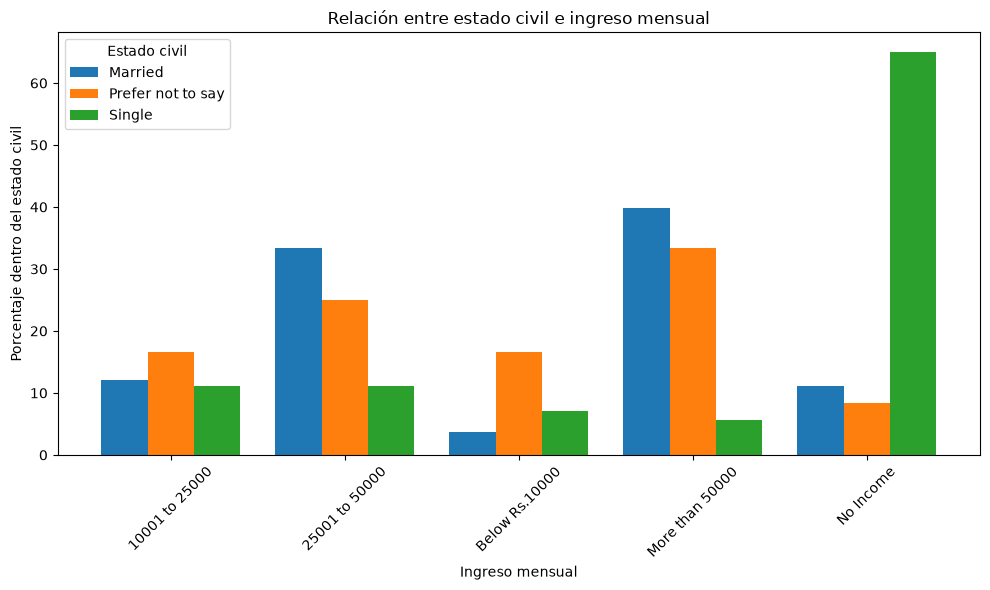

In [6]:
import matplotlib.pyplot as plt

tabla_porcentajes.T.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.8
)

plt.title("Relación entre estado civil e ingreso mensual")
plt.xlabel("Ingreso mensual")
plt.ylabel("Porcentaje dentro del estado civil")
plt.xticks(rotation=45)
plt.legend(title="Estado civil")
plt.tight_layout()
plt.show()

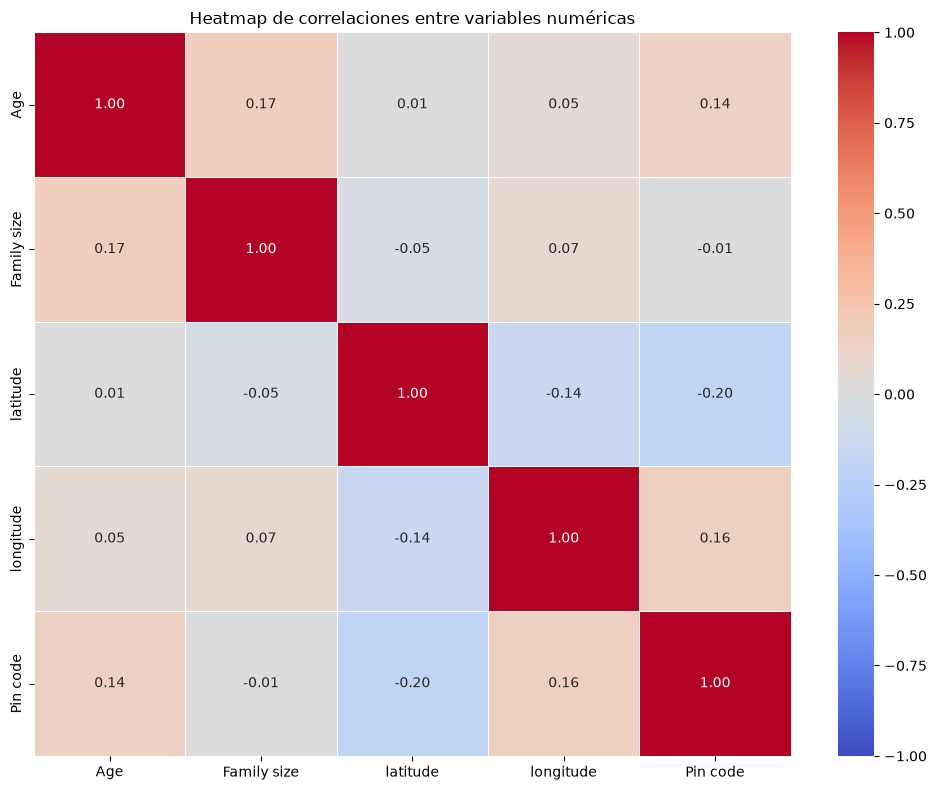

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar únicamente las variables numéricas
df_numerico = df.select_dtypes(include="number")

# Calcular la matriz de correlaciones
matriz_correlaciones = df_numerico.corr()

# Crear el heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_correlaciones,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Heatmap de correlaciones entre variables numéricas")
plt.tight_layout()
plt.show()

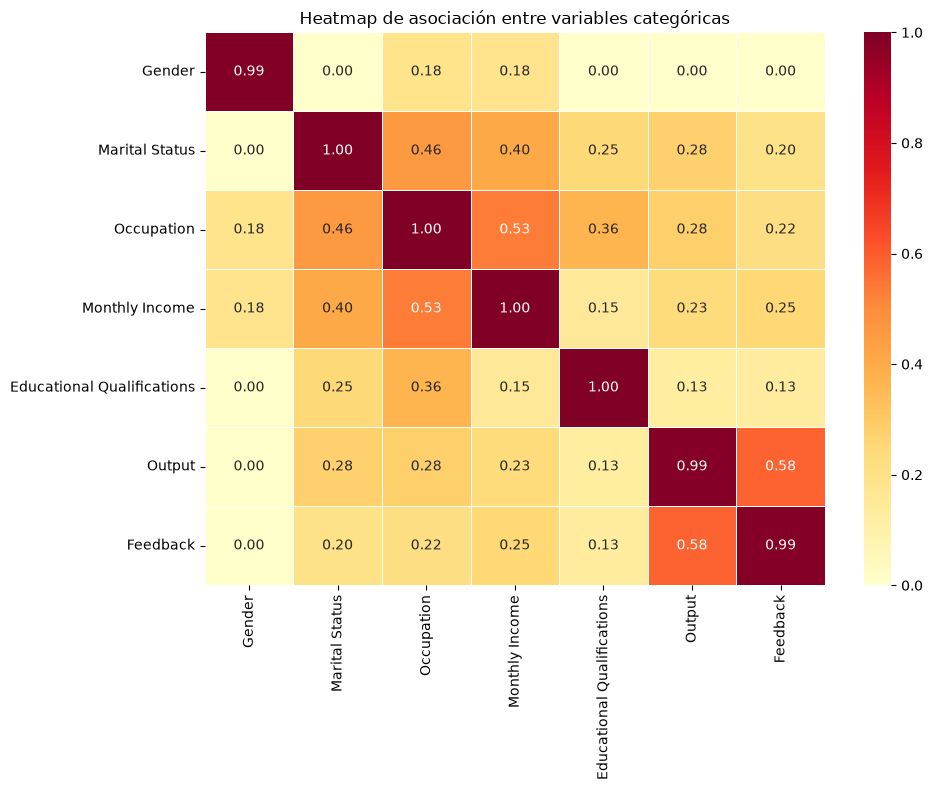

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Seleccionar las variables categóricas
variables_categoricas = [
    columna
    for columna, (tipo, _) in descripciones.items()
    if tipo == "categórico" and columna in df.columns
]

def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    phi2 = chi2 / n

    filas, columnas = tabla.shape
    phi2_corregido = max(
        0,
        phi2 - ((columnas - 1) * (filas - 1)) / (n - 1)
    )
    filas_corregidas = filas - ((filas - 1) ** 2) / (n - 1)
    columnas_corregidas = columnas - ((columnas - 1) ** 2) / (n - 1)

    return np.sqrt(
        phi2_corregido /
        max(1, min(columnas_corregidas - 1, filas_corregidas - 1))
    )

# Crear la matriz de asociaciones
matriz_categoricas = pd.DataFrame(
    index=variables_categoricas,
    columns=variables_categoricas,
    dtype=float
)

for variable_1 in variables_categoricas:
    for variable_2 in variables_categoricas:
        matriz_categoricas.loc[variable_1, variable_2] = cramers_v(
            df[variable_1],
            df[variable_2]
        )

# Crear el heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_categoricas,
    annot=True,
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Heatmap de asociación entre variables categóricas")
plt.tight_layout()
plt.show()

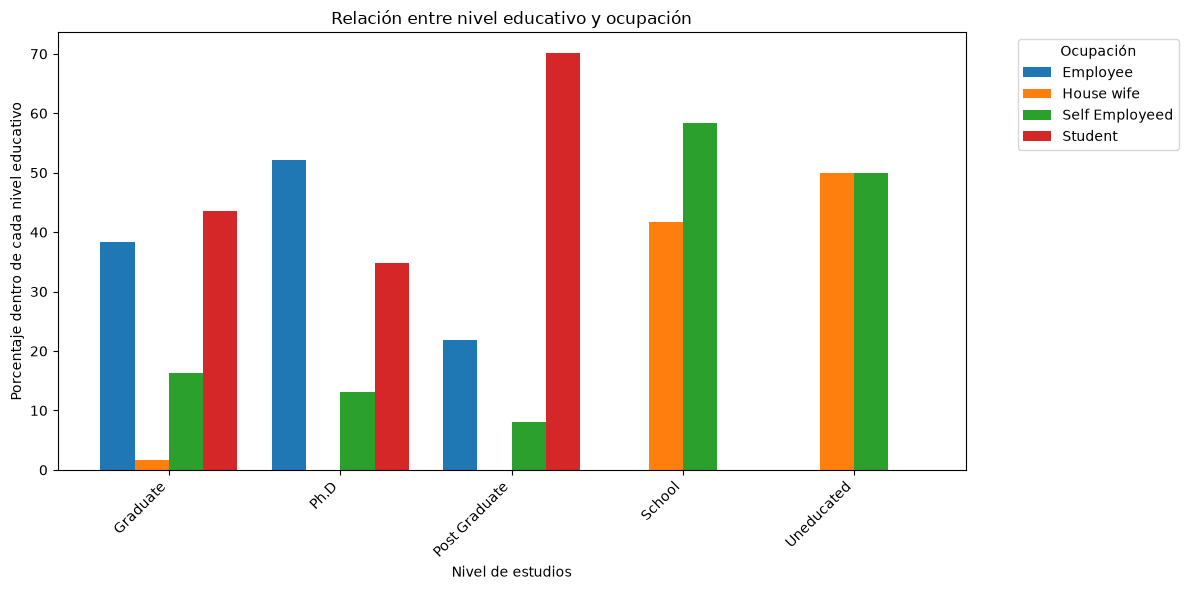

In [10]:
import matplotlib.pyplot as plt

tabla_educacion_ocupacion = pd.crosstab(
    df["Educational Qualifications"],
    df["Occupation"],
    normalize="index"
).mul(100)

tabla_educacion_ocupacion.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

plt.title("Relación entre nivel educativo y ocupación")
plt.xlabel("Nivel de estudios")
plt.ylabel("Porcentaje dentro de cada nivel educativo")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Ocupación", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
